# Capacitor Electrical Stress Dataset — Initial Data Processing
## Team Kansas Capstone: Predictive Maintenance for Aircraft Readiness

**Processed by**: Prem G (on behalf of Hrishikesh)  
**Dataset**: NASA CALCE Capacitor Electrical Stress (ES) Dataset  
**Date**: March 2026  

---

## Why Capacitor Data Matters for This Project

Aircraft avionics, power conditioning, and electronic control systems rely heavily on electrolytic capacitors. A degraded capacitor can cause:
- Voltage ripple → incorrect sensor readings
- Increased ESR (Equivalent Series Resistance) → heat and power loss
- Complete capacitance loss → system shutdown

By modeling how capacitors degrade under different voltage stress levels, we can:
1. Predict **Remaining Useful Life (RUL)** based on impedance drift
2. Compute a **health index** from capacitance and ESR changes
3. Flag components approaching failure before they affect flight safety

---

## Dataset Overview

The NASA CALCE Capacitor ES dataset contains **23 electrolytic capacitors** tested under three different voltage stress levels over approximately **6 months** (Nov 2014 – May 2015).

| File | Stress Level | Capacitors | Duration | File Size |
|------|-------------|-----------|---------|----------|
| ES10.mat | 10V electrical stress | 8 caps (C1–C8) | ~176 days | 1.1 GB |
| ES12.mat | 12V electrical stress | 8 caps (C1–C8) | ~177 days | 1.7 GB |
| ES14.mat | 14V electrical stress | 8 caps (C1–C8) | ~177 days | 2.0 GB |

**Note**: ES10 Transient_Data contains only C1–C7 (C8 only has EIS data).

### Two types of measurements per capacitor:

1. **Transient Data** — continuous voltage monitoring (every ~2–8 minutes)  
   - `VL` (Load Voltage): voltage under load — 58.8% populated in col 0 on average  
   - `VO` (Open-Circuit Voltage): voltage without load — 100% populated  

2. **EIS Data** — Electrochemical Impedance Spectroscopy (periodic sweeps, ~73 per capacitor)  
   - Sweeps 51 frequency points from 100 Hz to 100 kHz  
   - Key outputs: ESR (Equivalent Series Resistance), Re(Z), |Z|, Phase, Cs/Cp  

---

## Format Note

These files are MATLAB v7.3 HDF5 format — **NOT** the simple MATLAB format. They require `h5py` to read (not `scipy.io.loadmat`). The internal structure uses three levels of HDF5 object references that must be dereferenced to reach actual numerical data.

---
## Section 1: Library Imports and Setup

In [1]:
import os
import warnings
from datetime import datetime, timedelta

import numpy as np
import h5py                     # Required for MATLAB v7.3 (HDF5) files
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

print('All libraries loaded successfully.')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__} | h5py: {h5py.__version__}')

All libraries loaded successfully.
NumPy: 1.26.4 | Pandas: 2.2.2 | h5py: 3.11.0


---
## Section 2: Helper Functions

Before loading, we define two helper functions:

- **`matlab_serial_to_datetime`** — converts MATLAB serial date numbers to Python `datetime` objects. MATLAB counts days from January 1, year 0; we adjust for the Python epoch offset.
- **`extract_eis_block`** — navigates three levels of HDF5 object references to extract the actual `(18, 59)` EIS data matrix. This complexity is a quirk of how MATLAB v7.3 stores cell arrays internally.

In [2]:
def matlab_serial_to_datetime(serial):
    """
    Convert a MATLAB serial date number to a Python datetime.
    MATLAB serial date 1 = January 1, year 1 AD.
    Offset 367 = difference between MATLAB epoch and Python datetime(1,1,1).
    """
    try:
        return datetime(1, 1, 1) + timedelta(days=float(serial) - 367)
    except Exception:
        return None


def extract_eis_block(f, data_ds, row_i):
    """
    Dereference a single EIS sweep row from an HDF5 Data dataset.
    
    The MATLAB v7.3 HDF5 format stores EIS data as:
      Data[row_i, 0]  -> HDF5 reference to a (N, 1) cell array of sub-references
      cell[0, 0]      -> HDF5 reference to the actual (18, 59) float64 matrix
                         where: rows = 18 measurement variables
                                cols = 59 frequency points (first 8 are zero padding)
    
    Returns the (18, 59) numpy array, or None if the block is degenerate.
    """
    try:
        row_ref = data_ds[row_i, 0]
        d = f[row_ref]              # First dereference: cell array (N, 1)
        blk_ref = d[0, 0]           # Get first sub-block reference
        blk = np.array(f[blk_ref])  # Second dereference: actual (18, 59) matrix
        
        if blk.ndim != 2 or blk.shape[0] < 10 or blk.shape[1] < 10:
            return None  # Degenerate block (e.g., last row in ES10C1)
        return blk
    except Exception:
        return None


# EIS variable row mapping within the (18, 59) block
EIS_ROW_MAP = {
    'freq_hz':    0,   # Frequency axis (Hz)
    'ReZ_ohm':    1,   # Real part of impedance (Ohm) — grows with degradation
    'ImZ_ohm':    2,   # Negative imaginary part of impedance (stored as -Im(Z))
    'Zmag_ohm':   3,   # Impedance magnitude |Z| (Ohm)
    'Phase_deg':  4,   # Phase angle (degrees) — shifts toward 0° as capacitor degrades
    'time_s':     5,   # Elapsed time (s)
    'Ewe_V':      6,   # Working electrode voltage (V)
    'I_mA':       7,   # Current (mA)
    'Cs_uF':      8,   # Series capacitance (µF) — decreases with degradation
    'Cp_uF':      9,   # Parallel capacitance (µF)
}

print('Helper functions and EIS row map defined.')

Helper functions and EIS row map defined.


---
## Section 3: Data Loading

We load all three `.mat` files and build an inventory of what's inside. The files use HDF5 format so we use `h5py.File()` in read-only mode — we never load the full arrays into memory at once due to the 1–2 GB file sizes.

In [3]:
BASE_PATH = '12. Capacitor Electrical Stress'

# Dataset definition: stress_id -> filename
ES_FILES = {
    'ES10': os.path.join(BASE_PATH, 'ES10.mat'),
    'ES12': os.path.join(BASE_PATH, 'ES12.mat'),
    'ES14': os.path.join(BASE_PATH, 'ES14.mat'),
}

# Verify files exist and get sizes
print('=== File Inventory ===')
for es_id, fpath in ES_FILES.items():
    size_gb = os.path.getsize(fpath) / 1e9
    print(f'{es_id}: {fpath}  ({size_gb:.2f} GB)')

print()

# Inventory of capacitors per file
inventory_rows = []
for es_id, fpath in ES_FILES.items():
    with h5py.File(fpath, 'r') as f:
        grp = f[es_id]
        td  = grp['Transient_Data']
        eis = grp['EIS_Data']
        
        td_caps  = sorted([k for k in td.keys()  if k != 'Serial_Date'])
        eis_caps = sorted([k for k in eis.keys() if k != 'EIS_Reference_Table'])
        
        dates = td['Serial_Date'][:].flatten()
        start = matlab_serial_to_datetime(dates.min())
        end   = matlab_serial_to_datetime(dates.max())
        
        inventory_rows.append({
            'stress_id':          es_id,
            'n_transient_caps':   len(td_caps),
            'n_eis_caps':         len(eis_caps),
            'n_time_samples':     len(dates),
            'start_date':         start.strftime('%Y-%m-%d') if start else 'N/A',
            'end_date':           end.strftime('%Y-%m-%d')   if end   else 'N/A',
            'duration_days':      round(dates.max() - dates.min()),
            'transient_caps':     ', '.join(td_caps),
        })

df_inv = pd.DataFrame(inventory_rows)
print('=== Dataset Inventory ===')
print(df_inv[['stress_id','n_transient_caps','n_eis_caps','n_time_samples',
              'start_date','end_date','duration_days']].to_string(index=False))
print()
print('Total capacitors (transient):', df_inv['n_transient_caps'].sum())
print('Total capacitors (EIS):      ', df_inv['n_eis_caps'].sum())

=== File Inventory ===
ES10: 12. Capacitor Electrical Stress/ES10.mat  (1.21 GB)
ES12: 12. Capacitor Electrical Stress/ES12.mat  (1.86 GB)
ES14: 12. Capacitor Electrical Stress/ES14.mat  (2.09 GB)

=== Dataset Inventory ===
stress_id  n_transient_caps  n_eis_caps  n_time_samples start_date   end_date  duration_days
     ES10                 7           8           75826 2014-11-17 2015-05-12            176
     ES12                 8           8           77241 2014-11-17 2015-05-13            177
     ES14                 8           8           77241 2014-11-17 2015-05-13            177

Total capacitors (transient): 23
Total capacitors (EIS):       24


---
## Section 4: Parse EIS Data → One Row Per Sweep Per Capacitor

EIS (Electrochemical Impedance Spectroscopy) is the gold standard for capacitor health monitoring. It works by applying a small AC signal at multiple frequencies and measuring the impedance response. As a capacitor degrades:

- **ESR (Equivalent Series Resistance)** increases — more resistive loss
- **Cs (Series Capacitance)** decreases — less charge-storage ability
- **Phase angle** shifts toward 0° — ideal capacitor has -90° phase; real/degraded one is less negative

Each capacitor has **~69–73 EIS sweeps** over 6 months. We extract per-sweep summary features from the 51 valid frequency points (100 Hz to 100 kHz).

In [4]:
eis_rows = []

for es_id, fpath in ES_FILES.items():
    with h5py.File(fpath, 'r') as f:
        eis_grp = f[es_id]['EIS_Data']
        caps = sorted([k for k in eis_grp.keys() if k != 'EIS_Reference_Table'])
        
        for cap_id in caps:
            data_ds = eis_grp[cap_id]['EIS_Measurement']['Data']
            n_sweeps = data_ds.shape[0]
            sweep_count = 0
            
            for row_i in range(n_sweeps):
                blk = extract_eis_block(f, data_ds, row_i)
                if blk is None:
                    continue
                
                # Extract row arrays
                freq  = blk[EIS_ROW_MAP['freq_hz'],  :]
                re_z  = blk[EIS_ROW_MAP['ReZ_ohm'],  :]
                im_z  = blk[EIS_ROW_MAP['ImZ_ohm'],  :]  # stored as -Im(Z)
                z_mag = blk[EIS_ROW_MAP['Zmag_ohm'], :]
                phase = blk[EIS_ROW_MAP['Phase_deg'],:]
                cs    = blk[EIS_ROW_MAP['Cs_uF'],    :]
                cp    = blk[EIS_ROW_MAP['Cp_uF'],    :]
                
                # Keep only valid (non-zero) frequency points
                valid = freq != 0
                if valid.sum() < 5:
                    continue
                
                freq  = freq[valid]
                re_z  = re_z[valid]
                im_z  = im_z[valid]
                z_mag = z_mag[valid]
                phase = phase[valid]
                cs    = cs[valid]
                cp    = cp[valid]
                
                hi_idx = np.argmax(freq)   # highest frequency → ESR
                lo_idx = np.argmin(freq)   # lowest frequency → bulk capacitance
                
                # ESR = Re(Z) at highest frequency (pure resistive component)
                ESR = float(re_z[hi_idx])
                
                # Cs at low frequencies (most representative of bulk capacitance)
                cs_pos = cs[cs > 0]
                cp_pos = cp[cp > 0]
                
                sweep_count += 1
                eis_rows.append({
                    'stress_id':           es_id,
                    'capacitor_id':        cap_id,
                    'eis_sweep_num':       sweep_count,
                    'n_freq_points':       int(valid.sum()),
                    'freq_min_hz':         float(freq[lo_idx]),
                    'freq_max_hz':         float(freq[hi_idx]),
                    # ESR: most important degradation indicator — increases over time
                    'ESR_ohm':             ESR,
                    # Re(Z) at low freq captures bulk electrode resistance
                    'ReZ_lowfreq_ohm':     float(re_z[lo_idx]),
                    # -Im(Z) at low freq (positive = capacitive behaviour)
                    'ImZ_lowfreq_ohm':     float(im_z[lo_idx]),
                    # |Z| magnitude at low freq
                    'Zmag_lowfreq_ohm':    float(z_mag[lo_idx]),
                    # Phase: -90° = ideal cap; shifts toward 0° as degradation occurs
                    'Phase_lowfreq_deg':   float(phase[lo_idx]),
                    'Phase_mean_deg':      float(np.mean(phase)),
                    # Capacitance: decreases as capacitor ages
                    'Cs_mean_uF':          float(np.mean(cs_pos)) if len(cs_pos) > 0 else np.nan,
                    'Cp_mean_uF':          float(np.mean(cp_pos)) if len(cp_pos) > 0 else np.nan,
                    # Full-sweep averages for richer features
                    'ReZ_mean_ohm':        float(np.mean(re_z)),
                    'Zmag_mean_ohm':       float(np.mean(z_mag)),
                })

df_eis = pd.DataFrame(eis_rows)

print('EIS DataFrame shape:', df_eis.shape)
print()
print('EIS sweeps per stress group:')
print(df_eis.groupby('stress_id')['eis_sweep_num'].count())
print()
print('First 10 rows:')
df_eis.head(10)

EIS DataFrame shape: (1656, 16)

EIS sweeps per stress group:
stress_id
ES10    552
ES12    552
ES14    552
Name: eis_sweep_num, dtype: int64

First 10 rows:


,stress_id,capacitor_id,eis_sweep_num,n_freq_points,freq_min_hz,freq_max_hz,ESR_ohm,ReZ_lowfreq_ohm,ImZ_lowfreq_ohm,Zmag_lowfreq_ohm,Phase_lowfreq_deg,Phase_mean_deg,Cs_mean_uF,Cp_mean_uF,ReZ_mean_ohm,Zmag_mean_ohm
0,ES10,ES10C1,1,51,100.0320,100019.5080,0.1794,0.2504,0.8055,0.8435,-72.7294,-20.7667,1459.8719,466.5172,0.2040,0.2721
1,ES10,ES10C1,2,51,100.0320,100019.5080,0.1636,0.2347,0.8015,0.8351,-73.6812,-21.4848,1471.9198,474.8048,0.1929,0.2619
2,ES10,ES10C1,3,51,100.0320,100019.5080,0.2099,0.3559,0.8404,0.9127,-67.0450,-19.7447,1208.6926,363.5548,0.2574,0.3235
3,ES10,ES10C1,4,51,100.0320,100019.5080,0.2164,0.3580,0.8531,0.9252,-67.2344,-20.1093,1182.9903,344.3918,0.2602,0.3275
4,ES10,ES10C1,5,51,100.0320,100019.5080,0.2063,0.3431,0.8496,0.9163,-68.0086,-20.5971,1201.0428,348.4399,0.2494,0.3175
5,ES10,ES10C1,6,51,100.0320,100019.5080,0.1916,0.3251,0.8423,0.9029,-68.8967,-21.3289,1164.2787,350.0703,0.2357,0.3046
6,ES10,ES10C1,7,51,100.0320,100019.5080,0.2170,0.3383,0.8471,0.9122,-68.2322,-20.2945,1182.0352,346.5275,0.2539,0.3211
7,ES10,ES10C1,8,51,100.0320,100019.5080,0.2001,0.3299,0.8467,0.9087,-68.7141,-20.6029,1249.2821,364.0552,0.2437,0.3120
8,ES10,ES10C1,9,51,100.0320,100019.5080,0.2069,0.3380,0.8483,0.9132,-68.2744,-20.6193,1114.7189,341.3148,0.2515,0.3191
9,ES10,ES10C1,10,51,100.0320,100019.5080,0.1984,0.3244,0.8447,0.9049,-68.9903,-20.8994,1174.1902,351.9997,0.2417,0.3100


---
## Section 5: Parse Transient Data → Time-Series Voltage Summary

The transient data captures continuous voltage measurements while the capacitor is under its stress load. We sample the data into **daily summary statistics** rather than keeping all ~75,000 time-point rows per capacitor — this makes the dataset manageable while preserving the degradation trend.

**VO (Open-Circuit Voltage)** is the more reliable signal — it is 100% populated across all capacitors. **VL (Load Voltage)** is sparse (13–80% depending on capacitor) and is included where available.

We extract summary stats per **10-day window** (a practical bin size given the 176-day experiment).

In [5]:
transient_rows = []

WINDOW_DAYS = 10   # aggregate into 10-day summary bins

for es_id, fpath in ES_FILES.items():
    with h5py.File(fpath, 'r') as f:
        td = f[es_id]['Transient_Data']
        caps = sorted([k for k in td.keys() if k != 'Serial_Date'])
        
        # Shared timestamps for all capacitors in this file
        dates_serial = td['Serial_Date'][:].flatten()
        
        # Normalize to 'days since start' for each file
        days_elapsed = dates_serial - dates_serial.min()
        
        for cap_id in caps:
            # Read col 0 of VL and VO (the primary time-series channel)
            # We read only column 0 to keep memory manageable (1 col instead of 400)
            VL = td[cap_id]['VL'][:, 0]   # Load voltage at col 0
            VO = td[cap_id]['VO'][:, 0]   # Open-circuit voltage at col 0
            
            # ES12/ES14: VL/VO have 77237 rows but Serial_Date has 77241
            # Trim timestamps to match the actual array length
            n = len(VO)
            days_cap = days_elapsed[:n]
            
            # Aggregate into WINDOW_DAYS bins
            max_day = int(days_cap.max())
            bin_edges = np.arange(0, max_day + WINDOW_DAYS, WINDOW_DAYS)
            
            for bin_start in bin_edges[:-1]:
                bin_end = bin_start + WINDOW_DAYS
                mask = (days_cap >= bin_start) & (days_cap < bin_end)
                
                if mask.sum() == 0:
                    continue
                
                VO_win = VO[mask]
                VL_win = VL[mask]
                
                # VO is fully populated; VL has NaN gaps
                VO_valid = VO_win[~np.isnan(VO_win)]
                VL_valid = VL_win[~np.isnan(VL_win)]
                
                transient_rows.append({
                    'stress_id':          es_id,
                    'capacitor_id':       cap_id,
                    'window_start_day':   int(bin_start),
                    'window_end_day':     int(bin_end),
                    'n_samples_total':    int(mask.sum()),
                    # VO stats (always populated)
                    'VO_mean_V':          float(np.mean(VO_valid))  if len(VO_valid) > 0 else np.nan,
                    'VO_std_V':           float(np.std(VO_valid))   if len(VO_valid) > 0 else np.nan,
                    'VO_min_V':           float(np.min(VO_valid))   if len(VO_valid) > 0 else np.nan,
                    'VO_max_V':           float(np.max(VO_valid))   if len(VO_valid) > 0 else np.nan,
                    'VO_rms_V':           float(np.sqrt(np.mean(VO_valid**2))) if len(VO_valid) > 0 else np.nan,
                    # VL stats (sparse — may be NaN for whole window)
                    'VL_mean_V':          float(np.mean(VL_valid))  if len(VL_valid) > 0 else np.nan,
                    'VL_std_V':           float(np.std(VL_valid))   if len(VL_valid) > 0 else np.nan,
                    'VL_rms_V':           float(np.sqrt(np.mean(VL_valid**2))) if len(VL_valid) > 0 else np.nan,
                    'VL_valid_pct':       float(100 * len(VL_valid) / mask.sum()),
                })

df_transient = pd.DataFrame(transient_rows)

print('Transient DataFrame shape:', df_transient.shape)
print()
print('Rows per stress group:')
print(df_transient.groupby('stress_id')['window_start_day'].count())
print()
print('Missing values:')
print(df_transient.isnull().sum())
print()
print('First 10 rows:')
df_transient.head(10)

Transient DataFrame shape: (345, 14)

Rows per stress group:
stress_id
ES10    105
ES12    120
ES14    120
Name: window_start_day, dtype: int64

Missing values:
stress_id           0
capacitor_id        0
window_start_day    0
window_end_day      0
n_samples_total     0
VO_mean_V           0
VO_std_V            0
VO_min_V            0
VO_max_V            0
VO_rms_V            0
VL_mean_V           0
VL_std_V            0
VL_rms_V            0
VL_valid_pct        0
dtype: int64

First 10 rows:


,stress_id,capacitor_id,window_start_day,window_end_day,n_samples_total,VO_mean_V,VO_std_V,VO_min_V,VO_max_V,VO_rms_V,VL_mean_V,VL_std_V,VL_rms_V,VL_valid_pct
0,ES10,ES10C1,0,10,6205,-0.0220,0.1170,-0.2678,0.2783,0.1190,0.0490,0.0836,0.0969,67.3650
1,ES10,ES10C1,10,20,5461,-0.0277,0.1156,-0.2642,0.2288,0.1189,0.0569,0.0743,0.0936,59.9707
2,ES10,ES10C1,20,30,1536,-0.0348,0.1138,-0.2565,0.1915,0.1190,0.0639,0.0662,0.0920,51.1068
3,ES10,ES10C1,30,40,6313,-0.0293,0.1169,-0.2611,0.2303,0.1206,0.0614,0.0740,0.0962,56.7559
4,ES10,ES10C1,40,50,779,-0.0103,0.1174,-0.2264,0.2037,0.1179,0.0741,0.0743,0.1049,62.6444
5,ES10,ES10C1,60,70,4220,-0.0231,0.1173,-0.2647,0.1976,0.1196,0.0713,0.0704,0.1002,56.5640
6,ES10,ES10C1,70,80,7200,-0.0226,0.1179,-0.2647,0.2283,0.1201,0.0656,0.0751,0.0997,59.2639
7,ES10,ES10C1,80,90,5037,-0.0351,0.1160,-0.2621,0.2013,0.1212,0.0470,0.0776,0.0907,60.9291
8,ES10,ES10C1,90,100,6832,-0.0263,0.1174,-0.2640,0.2310,0.1204,0.0647,0.0733,0.0978,56.8355
9,ES10,ES10C1,100,110,7198,-0.0323,0.1189,-0.2660,0.2310,0.1233,0.0612,0.0733,0.0955,57.0158


---
## Section 6: Data Cleaning

### Known data quality issues:

| Issue | Location | Cause | Action |
|-------|----------|-------|--------|
| ES10 C8 missing from Transient_Data | ES10.mat | Not recorded | Flag: only EIS data available |
| VL sparse (13–80% per capacitor) | All files | Measurement gaps | Use VO as primary signal; flag VL coverage |
| Last EIS sweep degenerate (row 72 in some caps) | ES10 | Incomplete sweep at test end | Skipped during parsing (guard in extract_eis_block) |
| Zero-padding in frequency arrays | All EIS | MATLAB storage format | Filtered out using `freq != 0` mask |

We also check for statistical outliers in ESR and Cs using IQR bounds.

In [6]:
# --- Step 1: Missing value report ---
print('=== EIS Missing Values ===')
eis_null = df_eis.isnull().sum()
print(eis_null[eis_null > 0] if eis_null.sum() > 0 else 'No missing values in core EIS columns.')
print()

print('=== Transient Missing Values (expected for VL) ===')
tr_null = df_transient.isnull().sum()
print(tr_null[tr_null > 0])

=== EIS Missing Values ===
No missing values in core EIS columns.

=== Transient Missing Values (expected for VL) ===
Series([], dtype: int64)


In [7]:
# --- Step 2: Outlier detection on EIS ESR and Cs ---
# Using IQR method (3x bounds) + domain knowledge
# Domain knowledge: ESR for healthy electrolytic caps is typically 0.05–5 Ohm
# Cs should be positive and < 50,000 µF for standard electrolytics

for col, dom_lo, dom_hi in [('ESR_ohm', 0.001, 10.0), ('Cs_mean_uF', 1.0, 10000.0)]:
    Q1 = df_eis[col].quantile(0.25)
    Q3 = df_eis[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_lo = Q1 - 3*IQR
    iqr_hi = Q3 + 3*IQR
    
    stat_flag   = (df_eis[col] < iqr_lo) | (df_eis[col] > iqr_hi)
    domain_flag = (df_eis[col] < dom_lo) | (df_eis[col] > dom_hi)
    combined = stat_flag | domain_flag
    
    print(f'{col}: IQR bounds=[{iqr_lo:.4f}, {iqr_hi:.4f}], Domain bounds=[{dom_lo}, {dom_hi}]')
    print(f'  Flagged (IQR): {stat_flag.sum()} | Flagged (Domain): {domain_flag.sum()} | Total: {combined.sum()}')

print()

# Add outlier flag to EIS dataframe
Q1_esr = df_eis['ESR_ohm'].quantile(0.25)
Q3_esr = df_eis['ESR_ohm'].quantile(0.75)
IQR_esr = Q3_esr - Q1_esr

df_eis['is_outlier'] = (
    (df_eis['ESR_ohm'] < Q1_esr - 3*IQR_esr) |
    (df_eis['ESR_ohm'] > Q3_esr + 3*IQR_esr) |
    (df_eis['Cs_mean_uF'] > 10000) |
    (df_eis['ESR_ohm'] < 0.001)
)

print(f'Total EIS rows flagged as outlier: {df_eis["is_outlier"].sum()} of {len(df_eis)}')
if df_eis['is_outlier'].sum() > 0:
    print('Flagged rows:')
    print(df_eis[df_eis['is_outlier']][['stress_id','capacitor_id','eis_sweep_num','ESR_ohm','Cs_mean_uF']])

ESR_ohm: IQR bounds=[0.0862, 0.3942], Domain bounds=[0.001, 10.0]
  Flagged (IQR): 1 | Flagged (Domain): 0 | Total: 1
Cs_mean_uF: IQR bounds=[278.6223, 1927.7577], Domain bounds=[1.0, 10000.0]
  Flagged (IQR): 46 | Flagged (Domain): 10 | Total: 46

Total EIS rows flagged as outlier: 11 of 1656
Flagged rows:
     stress_id capacitor_id  eis_sweep_num  ESR_ohm  Cs_mean_uF
49        ES10       ES10C1             50   0.4362   1257.6230
259       ES10       ES10C4             53   0.2094  25336.7220
309       ES10       ES10C5             34   0.2337  12014.0714
366       ES10       ES10C6             22   0.2501  73464.4290
459       ES10       ES10C7             46   0.2205  11787.8594
798       ES12       ES12C4             40   0.2400  70927.8417
811       ES12       ES12C4             53   0.2202  10557.3506
962       ES12       ES12C6             66   0.2144 203615.4772
1197      ES14       ES14C2             25   0.2787  21381.5226
1273      ES14       ES14C3             32   0.2635

In [8]:
# --- Step 3: EIS descriptive statistics ---
print('EIS Feature Statistics:')
df_eis[['ESR_ohm','ReZ_lowfreq_ohm','Zmag_lowfreq_ohm',
        'Phase_lowfreq_deg','Cs_mean_uF','Cp_mean_uF']].describe().round(4)

EIS Feature Statistics:


,ESR_ohm,ReZ_lowfreq_ohm,Zmag_lowfreq_ohm,Phase_lowfreq_deg,Cs_mean_uF,Cp_mean_uF
count,1656.0000,1656.0000,1656.0000,1656.0000,1656.0000,1656.0000
mean,0.2390,0.3951,1.0152,-67.2210,1433.3678,319.1603
std,0.0316,0.0754,0.0727,3.3474,5667.3842,57.9088
min,0.1233,0.1711,0.8062,-77.7829,766.1602,219.1190
25%,0.2182,0.3418,0.9674,-69.6111,985.3946,279.3132
50%,0.2403,0.3933,1.0170,-67.3613,1088.8819,310.3695
75%,0.2622,0.4481,1.0750,-64.9119,1220.9854,348.6566
max,0.4362,0.5615,1.1652,-59.2430,203615.4772,584.8137


---
## Section 7: Exploratory Data Analysis

Now we visualize the degradation patterns across stress levels and capacitors.

### Plot 1: ESR Over Time by Stress Level

**What this shows**: How Equivalent Series Resistance grows across EIS sweeps for each capacitor group.  
**Why it matters**: ESR is the primary RUL indicator — a capacitor is considered failed when ESR exceeds a threshold (often 2× or 4× initial value). Higher voltage stress (ES14) should show faster ESR growth.

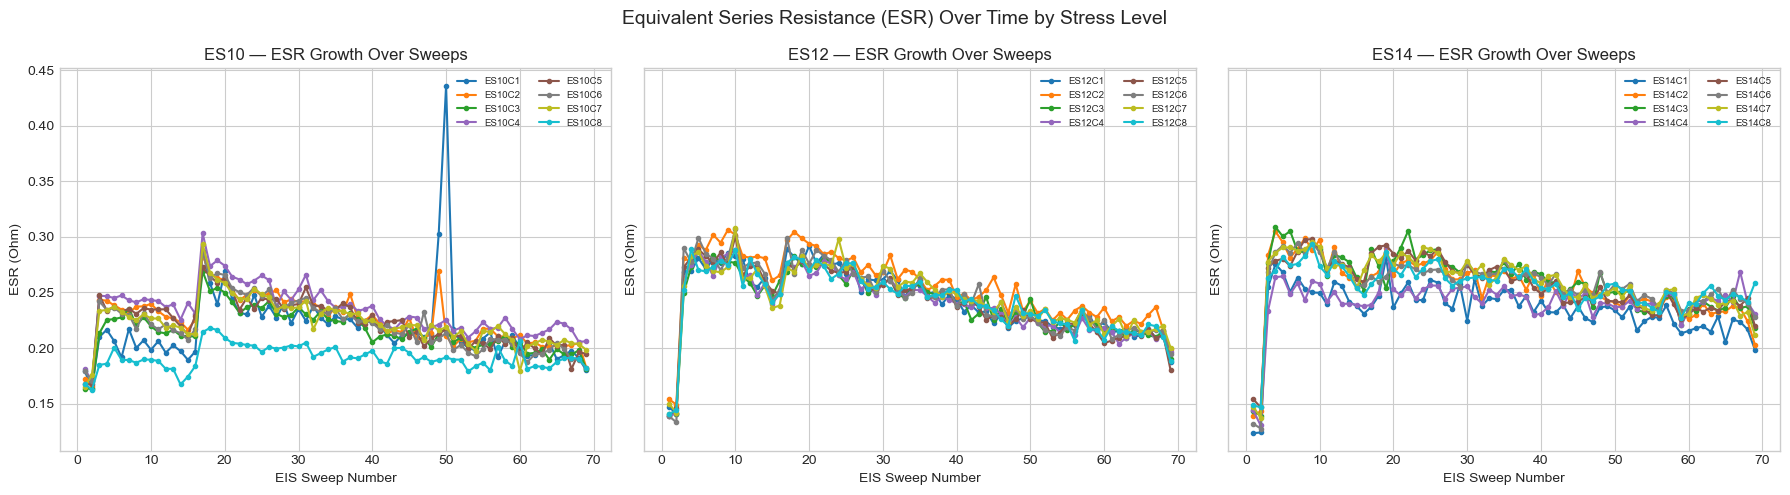

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
palette = {'ES10': 'steelblue', 'ES12': 'goldenrod', 'ES14': 'tomato'}

for ax, es_id in zip(axes, ['ES10', 'ES12', 'ES14']):
    grp = df_eis[df_eis['stress_id'] == es_id]
    caps = sorted(grp['capacitor_id'].unique())
    colors = cm.tab10(np.linspace(0, 1, len(caps)))
    
    for cap_id, color in zip(caps, colors):
        sub = grp[grp['capacitor_id'] == cap_id].sort_values('eis_sweep_num')
        ax.plot(sub['eis_sweep_num'], sub['ESR_ohm'],
                linewidth=1.5, marker='o', markersize=3,
                label=cap_id, color=color)
    
    ax.set_title(f'{es_id} — ESR Growth Over Sweeps', fontsize=12)
    ax.set_xlabel('EIS Sweep Number')
    ax.set_ylabel('ESR (Ohm)')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('Equivalent Series Resistance (ESR) Over Time by Stress Level', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 2: Series Capacitance (Cs) Over Time

**What this shows**: How Cs drops across sweeps.  
**Why it matters**: Lower capacitance = less charge-storage ability = degraded component. This is the capacitor equivalent of battery capacity fade.

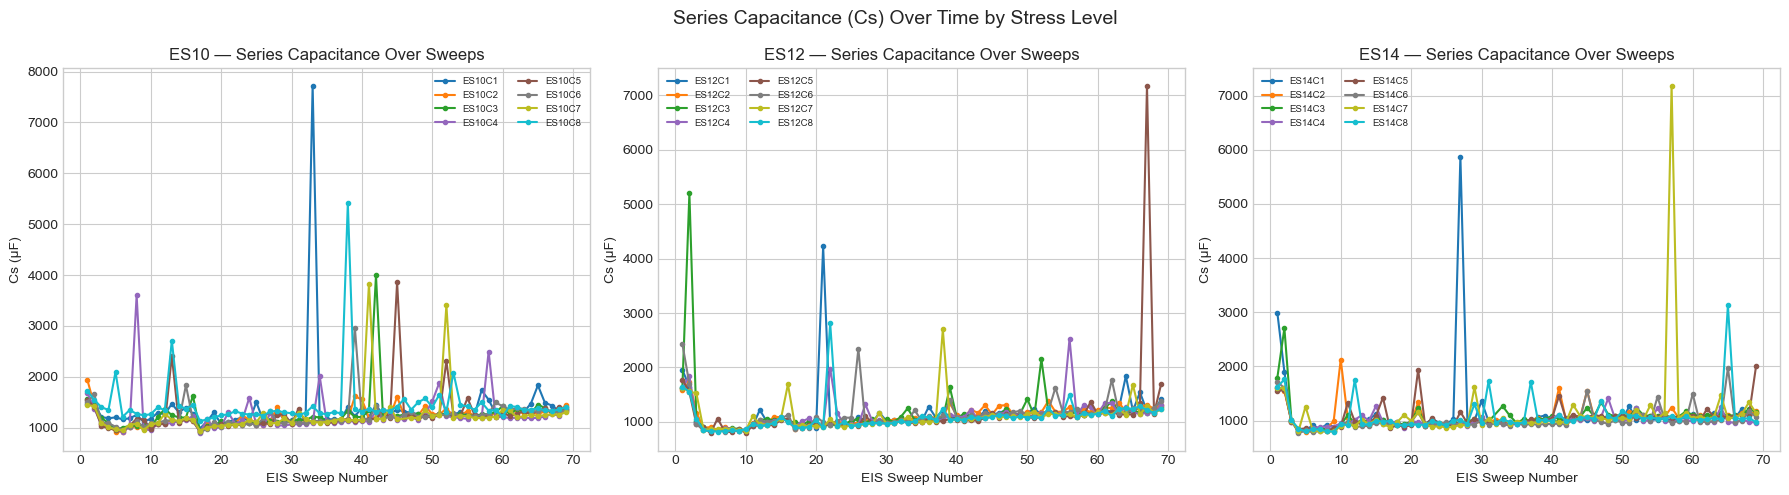

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, es_id in zip(axes, ['ES10', 'ES12', 'ES14']):
    grp = df_eis[(df_eis['stress_id'] == es_id) & (~df_eis['is_outlier'])]
    caps = sorted(grp['capacitor_id'].unique())
    colors = cm.tab10(np.linspace(0, 1, len(caps)))
    
    for cap_id, color in zip(caps, colors):
        sub = grp[grp['capacitor_id'] == cap_id].sort_values('eis_sweep_num')
        ax.plot(sub['eis_sweep_num'], sub['Cs_mean_uF'],
                linewidth=1.5, marker='o', markersize=3,
                label=cap_id, color=color)
    
    ax.set_title(f'{es_id} — Series Capacitance Over Sweeps', fontsize=12)
    ax.set_xlabel('EIS Sweep Number')
    ax.set_ylabel('Cs (µF)')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('Series Capacitance (Cs) Over Time by Stress Level', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 3: Phase Angle Over Time

**What this shows**: Phase angle at the lowest measured frequency.  
**Key insight**: An ideal capacitor has a phase angle of -90°. As the capacitor degrades and becomes more resistive, the phase angle shifts toward 0°. This trend across stress groups reveals how different voltage levels accelerate this shift.

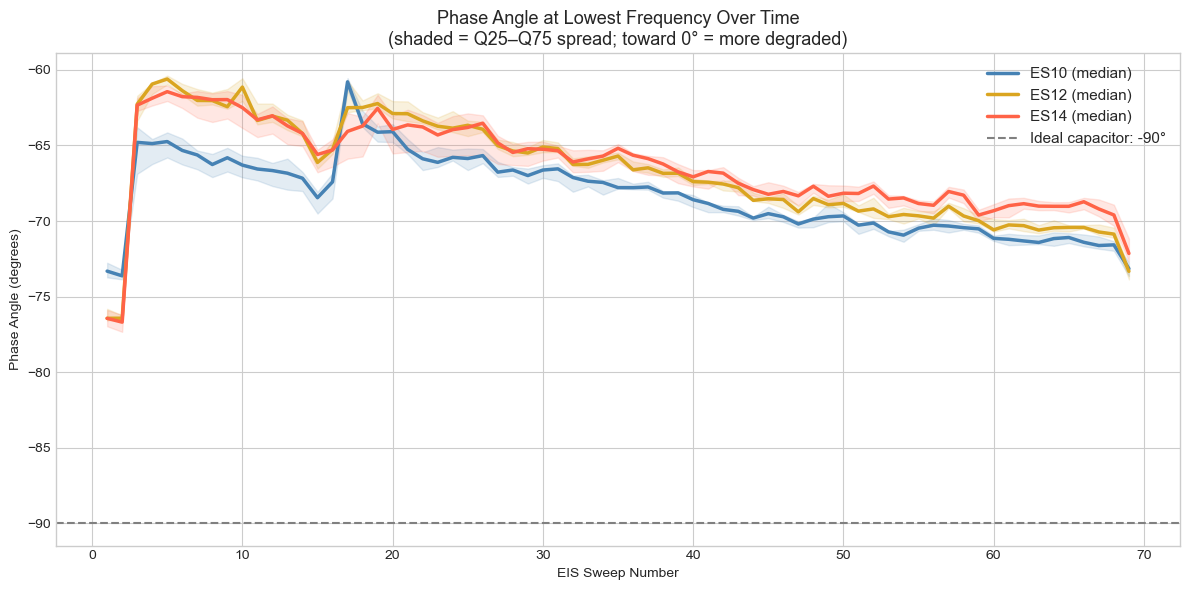

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

stress_palette = {'ES10': 'steelblue', 'ES12': 'goldenrod', 'ES14': 'tomato'}

for es_id, color in stress_palette.items():
    grp = df_eis[df_eis['stress_id'] == es_id]
    median_phase = grp.groupby('eis_sweep_num')['Phase_lowfreq_deg'].median()
    q25 = grp.groupby('eis_sweep_num')['Phase_lowfreq_deg'].quantile(0.25)
    q75 = grp.groupby('eis_sweep_num')['Phase_lowfreq_deg'].quantile(0.75)
    
    ax.plot(median_phase.index, median_phase.values,
            linewidth=2.5, label=f'{es_id} (median)', color=color)
    ax.fill_between(median_phase.index, q25, q75, alpha=0.15, color=color)

ax.axhline(y=-90, color='grey', linestyle='--', label='Ideal capacitor: -90°')
ax.set_title('Phase Angle at Lowest Frequency Over Time\n(shaded = Q25–Q75 spread; toward 0° = more degraded)', fontsize=13)
ax.set_xlabel('EIS Sweep Number')
ax.set_ylabel('Phase Angle (degrees)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Plot 4: Open-Circuit Voltage (VO) Drift Over Time

**What this shows**: Average VO over 10-day windows for all capacitors, grouped by stress level.  
**Why it matters**: VO drift (mean and standard deviation changing over time) is a direct signal of changing capacitor state under stress.

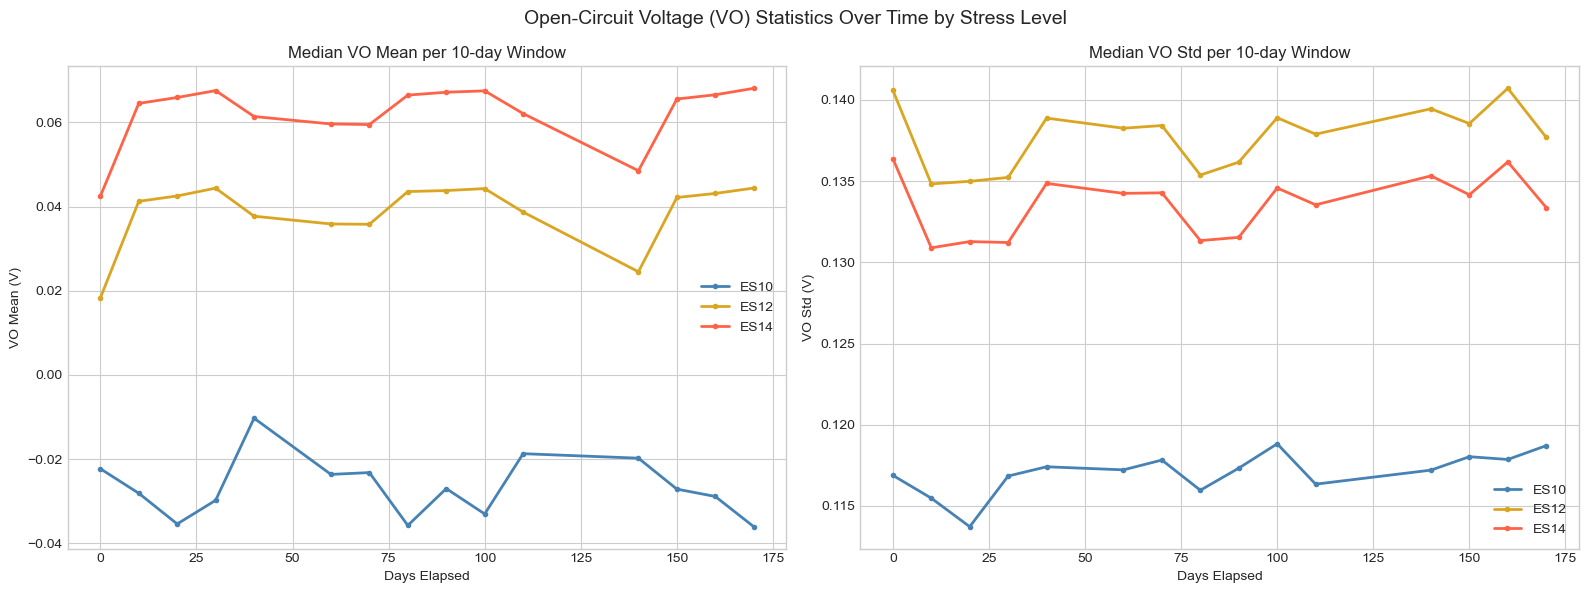

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for es_id, color in stress_palette.items():
    grp = df_transient[df_transient['stress_id'] == es_id]
    med_mean = grp.groupby('window_start_day')['VO_mean_V'].median()
    med_std  = grp.groupby('window_start_day')['VO_std_V'].median()
    
    axes[0].plot(med_mean.index, med_mean.values,
                 linewidth=2, label=es_id, color=color, marker='o', markersize=3)
    axes[1].plot(med_std.index, med_std.values,
                 linewidth=2, label=es_id, color=color, marker='o', markersize=3)

axes[0].set_title('Median VO Mean per 10-day Window', fontsize=12)
axes[0].set_xlabel('Days Elapsed')
axes[0].set_ylabel('VO Mean (V)')
axes[0].legend()

axes[1].set_title('Median VO Std per 10-day Window', fontsize=12)
axes[1].set_xlabel('Days Elapsed')
axes[1].set_ylabel('VO Std (V)')
axes[1].legend()

plt.suptitle('Open-Circuit Voltage (VO) Statistics Over Time by Stress Level', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 5: Correlation Heatmap of EIS Features

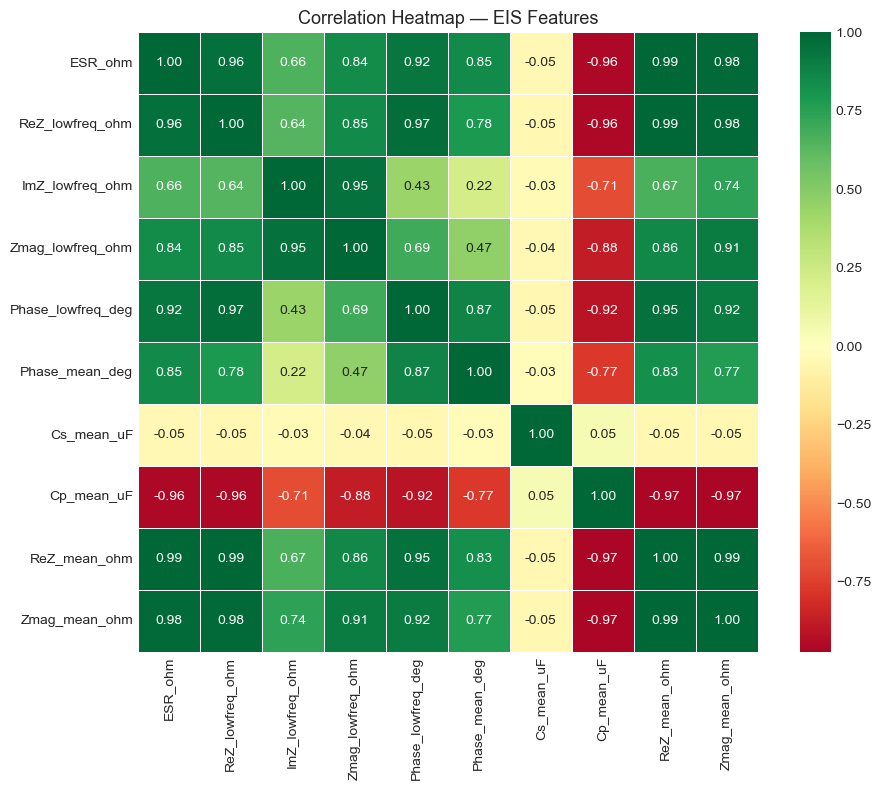

Strongest correlations with ESR_ohm:
ESR_ohm              1.0000
ReZ_mean_ohm         0.9902
Zmag_mean_ohm        0.9834
ReZ_lowfreq_ohm      0.9598
Phase_lowfreq_deg    0.9230
Phase_mean_deg       0.8494
Zmag_lowfreq_ohm     0.8418
ImZ_lowfreq_ohm      0.6560
Cs_mean_uF          -0.0483
Cp_mean_uF          -0.9595
Name: ESR_ohm, dtype: float64


In [13]:
eis_num_cols = ['ESR_ohm','ReZ_lowfreq_ohm','ImZ_lowfreq_ohm','Zmag_lowfreq_ohm',
                'Phase_lowfreq_deg','Phase_mean_deg','Cs_mean_uF','Cp_mean_uF',
                'ReZ_mean_ohm','Zmag_mean_ohm']

corr = df_eis[eis_num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — EIS Features', fontsize=13)
plt.tight_layout()
plt.show()

print('Strongest correlations with ESR_ohm:')
print(corr['ESR_ohm'].sort_values(ascending=False))

---
## Section 8: Feature Engineering — Health Index and RUL

### Approach

Unlike batteries (which have a clear capacity value counting down to EOL), capacitors don't have a single universally agreed failure threshold in this dataset. We use **ESR growth ratio** as the primary health indicator:

| Feature | Formula | Meaning |
|---------|----------|--------|
| **ESR_norm** | `ESR / ESR_initial` | ESR growth ratio (1.0 at start, grows with age) |
| **Cs_norm** | `Cs / Cs_initial` | Capacitance retention ratio (1.0 at start, decreases) |
| **Phase_shift** | `Phase_lowfreq - Phase_initial` | Phase drift toward 0° |
| **Health_Index** | `Cs_norm × (2 - ESR_norm)` | Composite score: 1.0 = healthy, 0.0 = failed |
| **RUL** | `EOL_sweep - current_sweep` | Sweeps remaining until ESR doubles (2× initial) |
| **ESR_fade_rate** | Rolling slope of ESR over last 5 sweeps | Rate of degradation |

**EOL criterion**: ESR exceeds 2× its initial value (common industry threshold for electrolytic capacitors).

In [14]:
EOL_ESR_MULTIPLIER = 2.0  # EOL when ESR reaches 2× initial value

def rolling_slope(series, window=5):
    """Compute rolling linear slope over a window of past values."""
    slopes = [np.nan] * len(series)
    vals = series.values
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(np.arange(window), y, 1)[0]
    return slopes


feature_rows = []

for (es_id, cap_id), grp in df_eis.groupby(['stress_id', 'capacitor_id']):
    grp = grp.sort_values('eis_sweep_num').copy()
    
    # Initial values from first 3 non-outlier sweeps (median for robustness)
    valid_init = grp[~grp['is_outlier']].head(3)
    if len(valid_init) == 0:
        continue
    
    ESR_0   = valid_init['ESR_ohm'].median()
    Cs_0    = valid_init['Cs_mean_uF'].median()
    Phase_0 = valid_init['Phase_lowfreq_deg'].median()
    
    if ESR_0 == 0 or np.isnan(ESR_0):
        continue
    
    # Normalized features
    grp['ESR_norm']    = grp['ESR_ohm']          / ESR_0
    grp['Cs_norm']     = grp['Cs_mean_uF']        / Cs_0 if Cs_0 and Cs_0 > 0 else np.nan
    grp['Phase_shift'] = grp['Phase_lowfreq_deg'] - Phase_0
    
    # Composite Health Index (0=failed, 1=healthy)
    # Cs_norm × (2 - ESR_norm): when ESR doubles (ESR_norm=2), ESR term = 0; clipped to [0, 1]
    grp['Health_Index'] = (grp['Cs_norm'] * (2.0 - grp['ESR_norm'])).clip(0, 1)
    
    # EOL: first sweep where ESR exceeds EOL_ESR_MULTIPLIER × initial ESR
    EOL_threshold = ESR_0 * EOL_ESR_MULTIPLIER
    eol_rows = grp[grp['ESR_ohm'] >= EOL_threshold]
    
    if len(eol_rows) > 0:
        eol_sweep = int(eol_rows['eis_sweep_num'].iloc[0])
        is_censored = False
    else:
        # Capacitor didn't reach EOL within the experiment — right-censored
        eol_sweep   = int(grp['eis_sweep_num'].max())
        is_censored = True
    
    grp['RUL']         = (eol_sweep - grp['eis_sweep_num']).clip(lower=0)
    grp['is_censored'] = is_censored
    grp['cycle_normalized'] = grp['eis_sweep_num'] / eol_sweep
    
    # ESR rolling slope (rate of degradation)
    grp['ESR_fade_rate'] = rolling_slope(grp['ESR_ohm'])
    
    # Rolling stats on Health Index
    grp['HI_rolling_mean'] = grp['Health_Index'].rolling(window=5, min_periods=1).mean()
    grp['HI_rolling_std']  = grp['Health_Index'].rolling(window=5, min_periods=1).std().fillna(0)
    
    feature_rows.append(grp)

df_features = pd.concat(feature_rows, ignore_index=True)

print('Feature DataFrame shape:', df_features.shape)
print()
print('Sample features:')
df_features[['stress_id','capacitor_id','eis_sweep_num','ESR_ohm','ESR_norm',
              'Cs_norm','Health_Index','RUL','is_censored']].head(15)

Feature DataFrame shape: (1656, 27)

Sample features:


,stress_id,capacitor_id,eis_sweep_num,ESR_ohm,ESR_norm,Cs_norm,Health_Index,RUL,is_censored
0,ES10,ES10C1,1,0.1794,1.0000,1.0000,1.0000,49,False
1,ES10,ES10C1,2,0.1636,0.9122,1.0083,1.0000,48,False
2,ES10,ES10C1,3,0.2099,1.1703,0.8279,0.6870,47,False
3,ES10,ES10C1,4,0.2164,1.2066,0.8103,0.6429,46,False
4,ES10,ES10C1,5,0.2063,1.1501,0.8227,0.6992,45,False
5,ES10,ES10C1,6,0.1916,1.0680,0.7975,0.7433,44,False
6,ES10,ES10C1,7,0.2170,1.2099,0.8097,0.6397,43,False
7,ES10,ES10C1,8,0.2001,1.1154,0.8557,0.7570,42,False
8,ES10,ES10C1,9,0.2069,1.1536,0.7636,0.6463,41,False
9,ES10,ES10C1,10,0.1984,1.1061,0.8043,0.7190,40,False


In [15]:
# Feature statistics summary
feat_cols = ['ESR_ohm','ESR_norm','Cs_norm','Phase_shift',
             'Health_Index','RUL','ESR_fade_rate','HI_rolling_mean','HI_rolling_std']

print('Feature Statistics:')
df_features[feat_cols].describe().round(4)

Feature Statistics:


,ESR_ohm,ESR_norm,Cs_norm,Phase_shift,Health_Index,RUL,ESR_fade_rate,HI_rolling_mean,HI_rolling_std
count,1656.0000,1656.0000,1656.0000,1656.0000,1656.0000,1656.0000,1560.0000,1656.0000,1656.0000
mean,0.2390,1.5537,0.9368,7.4855,0.3760,17.8442,0.0002,0.3865,0.0813
std,0.0316,0.3135,3.4302,4.5860,0.3025,21.9809,0.0069,0.2910,0.1078
min,0.1233,0.5572,0.4198,-13.2794,0.0000,0.0000,-0.0493,0.0000,0.0000
25%,0.2182,1.2802,0.6175,4.6711,0.1119,0.0000,-0.0028,0.1228,0.0271
50%,0.2403,1.5731,0.7114,7.4978,0.3077,4.0000,-0.0010,0.3356,0.0430
75%,0.2622,1.8227,0.8458,10.8829,0.6203,35.0000,0.0010,0.6378,0.0750
max,0.4362,2.4314,120.0221,16.6538,1.0000,68.0000,0.0534,1.0000,0.5774


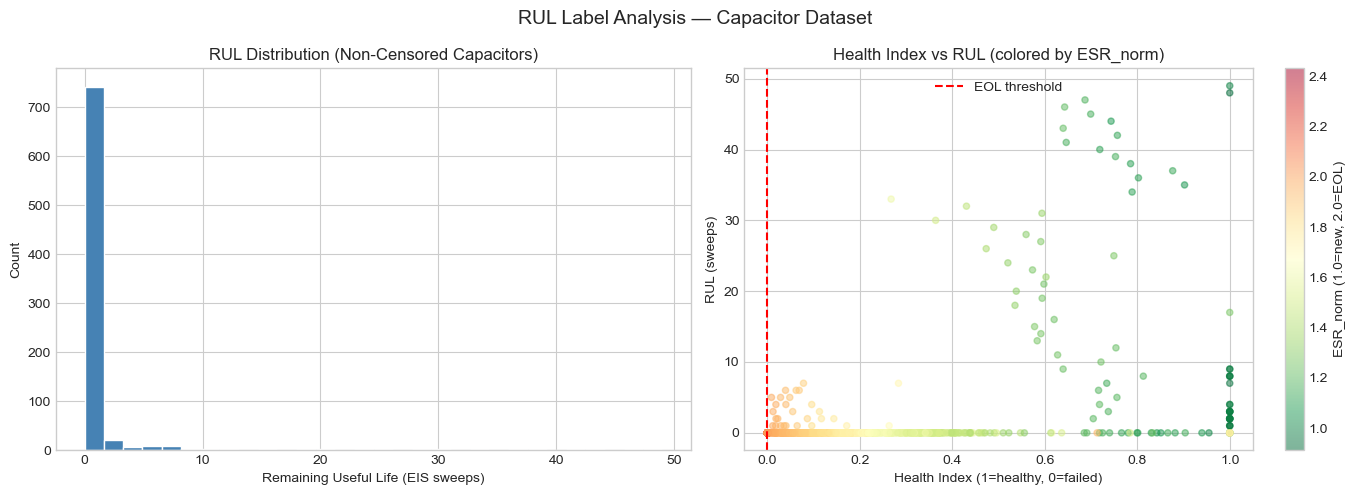

Censored capacitors: 12
Non-censored capacitors: 12
RUL range (non-censored): 0 — 49 sweeps


In [16]:
# RUL Distribution and Health Index vs RUL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nc = df_features[~df_features['is_censored']]
axes[0].hist(nc['RUL'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('RUL Distribution (Non-Censored Capacitors)', fontsize=12)
axes[0].set_xlabel('Remaining Useful Life (EIS sweeps)')
axes[0].set_ylabel('Count')

sc = axes[1].scatter(
    nc['Health_Index'], nc['RUL'],
    c=nc['ESR_norm'],
    cmap='RdYlGn_r', alpha=0.5, s=20
)
plt.colorbar(sc, ax=axes[1], label='ESR_norm (1.0=new, 2.0=EOL)')
axes[1].set_title('Health Index vs RUL (colored by ESR_norm)', fontsize=12)
axes[1].set_xlabel('Health Index (1=healthy, 0=failed)')
axes[1].set_ylabel('RUL (sweeps)')
axes[1].axvline(x=0, color='red', linestyle='--', label='EOL threshold')
axes[1].legend()

plt.suptitle('RUL Label Analysis — Capacitor Dataset', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Censored capacitors: {df_features[df_features["is_censored"]]["capacitor_id"].nunique()}')
print(f'Non-censored capacitors: {df_features[~df_features["is_censored"]]["capacitor_id"].nunique()}')
if len(nc) > 0:
    print(f'RUL range (non-censored): {nc["RUL"].min():.0f} — {nc["RUL"].max():.0f} sweeps')

---
## Section 9: Dependency Analysis

### Connection to Battery Dataset (Prem)
Both datasets use:
- **RUL counting down to 0** at end-of-life — identical schema, compatible for joint modeling
- **Normalized health features** (`ESR_norm` ↔ `SOH`): both describe how much life is used (0–1 scale)
- **Impedance features**: Battery uses `Re_norm`/`Rct_norm`; capacitors use `ESR_norm`. Conceptually the same degradation signal — ESR increase in capacitors is analogous to Re growth in batteries

### Connection to CMAPSS Engine Health (Deveshree)
All three RUL datasets (Battery, Capacitor, CMAPSS) use the same RUL countdown convention. The composite aircraft **Health Index** can combine:
```
Health_Index_aircraft = w1 × Battery_SOH + w2 × Capacitor_HI + w3 × Engine_RUL_norm
```

### Connection to Weather API (Jal)
Voltage stress on capacitors is temperature-dependent — hot environments accelerate ESR growth. The `stress_id` (ES10/ES12/ES14) represents test conditions that can be calibrated against real operating temperatures from weather data.

### What ML teammates need from this dataset

| Feature | Used for |
|---------|----------|
| `RUL` | RUL regression (join with battery + CMAPSS) |
| `Health_Index` | Composite health score computation |
| `ESR_norm` | Degradation severity feature |
| `Cs_norm` | Capacitance retention (0–1) |
| `ESR_fade_rate` | Rate of degradation — early warning |
| `is_censored` | Survival analysis flag |
| `stress_id` | Operating condition (voltage level proxy) |

---
## Section 10: Export Final CSVs

Two output files:
1. **`capacitor_eis_summary.csv`** — raw cleaned EIS data, one row per sweep per capacitor  
2. **`capacitor_rul_features.csv`** — engineered ML-ready features with RUL labels

In [17]:
# ============================================================
# CSV 1: capacitor_eis_summary.csv
# Raw cleaned EIS data — one row per sweep per capacitor
# ============================================================

eis_summary_cols = [
    'stress_id', 'capacitor_id', 'eis_sweep_num',
    'n_freq_points', 'freq_min_hz', 'freq_max_hz',
    'ESR_ohm', 'ReZ_lowfreq_ohm', 'ImZ_lowfreq_ohm',
    'Zmag_lowfreq_ohm', 'Phase_lowfreq_deg', 'Phase_mean_deg',
    'Cs_mean_uF', 'Cp_mean_uF', 'ReZ_mean_ohm', 'Zmag_mean_ohm',
    'is_outlier'
]

df_eis_out = df_eis[eis_summary_cols].copy()
df_eis_out.to_csv('capacitor_eis_summary.csv', index=False)

print('=== capacitor_eis_summary.csv ===')
print(f'Shape: {df_eis_out.shape}')
print(f'Columns: {list(df_eis_out.columns)}')
print()
print('First 5 rows:')
df_eis_out.head(5)

=== capacitor_eis_summary.csv ===
Shape: (1656, 17)
Columns: ['stress_id', 'capacitor_id', 'eis_sweep_num', 'n_freq_points', 'freq_min_hz', 'freq_max_hz', 'ESR_ohm', 'ReZ_lowfreq_ohm', 'ImZ_lowfreq_ohm', 'Zmag_lowfreq_ohm', 'Phase_lowfreq_deg', 'Phase_mean_deg', 'Cs_mean_uF', 'Cp_mean_uF', 'ReZ_mean_ohm', 'Zmag_mean_ohm', 'is_outlier']

First 5 rows:


,stress_id,capacitor_id,eis_sweep_num,n_freq_points,freq_min_hz,freq_max_hz,ESR_ohm,ReZ_lowfreq_ohm,ImZ_lowfreq_ohm,Zmag_lowfreq_ohm,Phase_lowfreq_deg,Phase_mean_deg,Cs_mean_uF,Cp_mean_uF,ReZ_mean_ohm,Zmag_mean_ohm,is_outlier
0,ES10,ES10C1,1,51,100.0320,100019.5080,0.1794,0.2504,0.8055,0.8435,-72.7294,-20.7667,1459.8719,466.5172,0.2040,0.2721,False
1,ES10,ES10C1,2,51,100.0320,100019.5080,0.1636,0.2347,0.8015,0.8351,-73.6812,-21.4848,1471.9198,474.8048,0.1929,0.2619,False
2,ES10,ES10C1,3,51,100.0320,100019.5080,0.2099,0.3559,0.8404,0.9127,-67.0450,-19.7447,1208.6926,363.5548,0.2574,0.3235,False
3,ES10,ES10C1,4,51,100.0320,100019.5080,0.2164,0.3580,0.8531,0.9252,-67.2344,-20.1093,1182.9903,344.3918,0.2602,0.3275,False
4,ES10,ES10C1,5,51,100.0320,100019.5080,0.2063,0.3431,0.8496,0.9163,-68.0086,-20.5971,1201.0428,348.4399,0.2494,0.3175,False


In [18]:
# ============================================================
# CSV 2: capacitor_rul_features.csv
# ML-ready features with RUL labels
# ============================================================

rul_cols = [
    'stress_id', 'capacitor_id', 'eis_sweep_num',
    'ESR_ohm', 'ESR_norm', 'Cs_norm', 'Phase_shift',
    'Health_Index', 'RUL', 'is_censored',
    'ESR_fade_rate', 'HI_rolling_mean', 'HI_rolling_std',
    'cycle_normalized', 'ReZ_mean_ohm', 'Zmag_mean_ohm'
]

df_rul = df_features[rul_cols].copy()
df_rul.to_csv('capacitor_rul_features.csv', index=False)

print('=== capacitor_rul_features.csv ===')
print(f'Shape: {df_rul.shape}')
print(f'Columns: {list(df_rul.columns)}')
print()
print('First 5 rows:')
df_rul.head(5)

=== capacitor_rul_features.csv ===
Shape: (1656, 16)
Columns: ['stress_id', 'capacitor_id', 'eis_sweep_num', 'ESR_ohm', 'ESR_norm', 'Cs_norm', 'Phase_shift', 'Health_Index', 'RUL', 'is_censored', 'ESR_fade_rate', 'HI_rolling_mean', 'HI_rolling_std', 'cycle_normalized', 'ReZ_mean_ohm', 'Zmag_mean_ohm']

First 5 rows:


,stress_id,capacitor_id,eis_sweep_num,ESR_ohm,ESR_norm,Cs_norm,Phase_shift,Health_Index,RUL,is_censored,ESR_fade_rate,HI_rolling_mean,HI_rolling_std,cycle_normalized,ReZ_mean_ohm,Zmag_mean_ohm
0,ES10,ES10C1,1,0.1794,1.0000,1.0000,0.0000,1.0000,49,False,NaN,1.0000,0.0000,0.0200,0.2040,0.2721
1,ES10,ES10C1,2,0.1636,0.9122,1.0083,-0.9518,1.0000,48,False,NaN,1.0000,0.0000,0.0400,0.1929,0.2619
2,ES10,ES10C1,3,0.2099,1.1703,0.8279,5.6844,0.6870,47,False,NaN,0.8957,0.1807,0.0600,0.2574,0.3235
3,ES10,ES10C1,4,0.2164,1.2066,0.8103,5.4950,0.6429,46,False,NaN,0.8325,0.1943,0.0800,0.2602,0.3275
4,ES10,ES10C1,5,0.2063,1.1501,0.8227,4.7207,0.6992,45,False,0.0107,0.8058,0.1785,0.1000,0.2494,0.3175


In [19]:
# ============================================================
# CSV 3: capacitor_transient_summary.csv
# Voltage time-series aggregated into 10-day windows
# ============================================================

df_transient.to_csv('capacitor_transient_summary.csv', index=False)

print('=== capacitor_transient_summary.csv ===')
print(f'Shape: {df_transient.shape}')
print(f'Columns: {list(df_transient.columns)}')
print()
print('First 5 rows:')
df_transient.head(5)

=== capacitor_transient_summary.csv ===
Shape: (345, 14)
Columns: ['stress_id', 'capacitor_id', 'window_start_day', 'window_end_day', 'n_samples_total', 'VO_mean_V', 'VO_std_V', 'VO_min_V', 'VO_max_V', 'VO_rms_V', 'VL_mean_V', 'VL_std_V', 'VL_rms_V', 'VL_valid_pct']

First 5 rows:


,stress_id,capacitor_id,window_start_day,window_end_day,n_samples_total,VO_mean_V,VO_std_V,VO_min_V,VO_max_V,VO_rms_V,VL_mean_V,VL_std_V,VL_rms_V,VL_valid_pct
0,ES10,ES10C1,0,10,6205,-0.0220,0.1170,-0.2678,0.2783,0.1190,0.0490,0.0836,0.0969,67.3650
1,ES10,ES10C1,10,20,5461,-0.0277,0.1156,-0.2642,0.2288,0.1189,0.0569,0.0743,0.0936,59.9707
2,ES10,ES10C1,20,30,1536,-0.0348,0.1138,-0.2565,0.1915,0.1190,0.0639,0.0662,0.0920,51.1068
3,ES10,ES10C1,30,40,6313,-0.0293,0.1169,-0.2611,0.2303,0.1206,0.0614,0.0740,0.0962,56.7559
4,ES10,ES10C1,40,50,779,-0.0103,0.1174,-0.2264,0.2037,0.1179,0.0741,0.0743,0.1049,62.6444


In [20]:
# ============================================================
# Final Summary
# ============================================================

print('=' * 55)
print('       FINAL DATASET SUMMARY')
print('=' * 55)
print()
print(f'Total capacitors processed:       {df_rul["capacitor_id"].nunique()}')
print(f'Total EIS sweeps (clean):         {len(df_eis_out)}')
print(f'Total transient windows:          {len(df_transient)}')
print(f'Outlier EIS sweeps flagged:       {df_eis_out["is_outlier"].sum()}')
print(f'Censored capacitors:              {df_rul[df_rul["is_censored"]]["capacitor_id"].nunique()}')
print()

nc = df_rul[~df_rul['is_censored']]
if len(nc) > 0:
    print(f'RUL range (non-censored):  {nc["RUL"].min():.0f} — {nc["RUL"].max():.0f} sweeps')
    print(f'Mean RUL (non-censored):   {nc["RUL"].mean():.1f} sweeps')
else:
    print('All capacitors are right-censored (ESR never doubled in experiment window).')
print()
print(f'Health Index range: {df_rul["Health_Index"].min():.3f} — {df_rul["Health_Index"].max():.3f}')
print(f'ESR_norm range:     {df_rul["ESR_norm"].min():.3f} — {df_rul["ESR_norm"].max():.3f}')
print()
print('EIS sweeps per stress level:')
print(df_rul.groupby('stress_id')['eis_sweep_num'].count())
print()
print('Files saved:')
print('  - capacitor_eis_summary.csv')
print('  - capacitor_rul_features.csv')
print('  - capacitor_transient_summary.csv')

       FINAL DATASET SUMMARY

Total capacitors processed:       24
Total EIS sweeps (clean):         1656
Total transient windows:          345
Outlier EIS sweeps flagged:       11
Censored capacitors:              12

RUL range (non-censored):  0 — 49 sweeps
Mean RUL (non-censored):   1.7 sweeps

Health Index range: 0.000 — 1.000
ESR_norm range:     0.557 — 2.431

EIS sweeps per stress level:
stress_id
ES10    552
ES12    552
ES14    552
Name: eis_sweep_num, dtype: int64

Files saved:
  - capacitor_eis_summary.csv
  - capacitor_rul_features.csv
  - capacitor_transient_summary.csv
